In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Предобработка данных

In [2]:
df = pd.read_csv('Advertising.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [3]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [4]:
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Пропусков нет

In [5]:
df.duplicated().sum()

np.int64(0)

Дубликатов тоже

<function matplotlib.pyplot.show(close=None, block=None)>

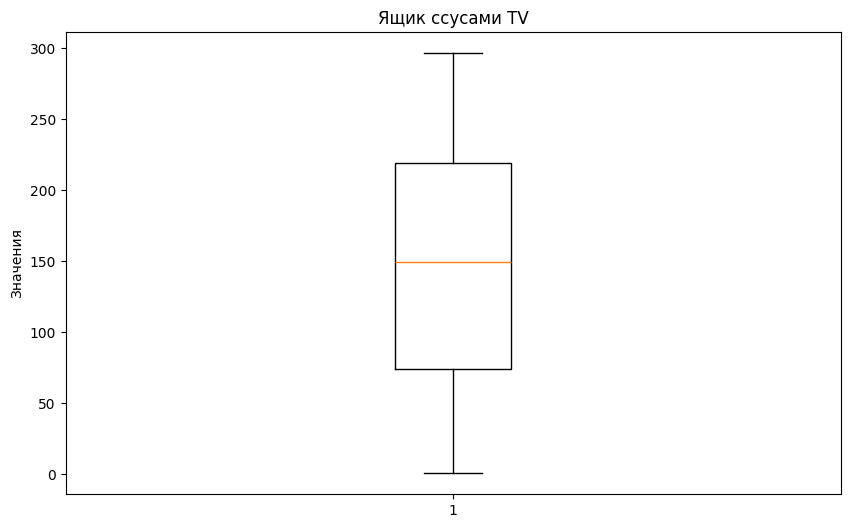

In [6]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['TV'])
plt.ylabel('Значения')
plt.title('Ящик сcусами TV')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

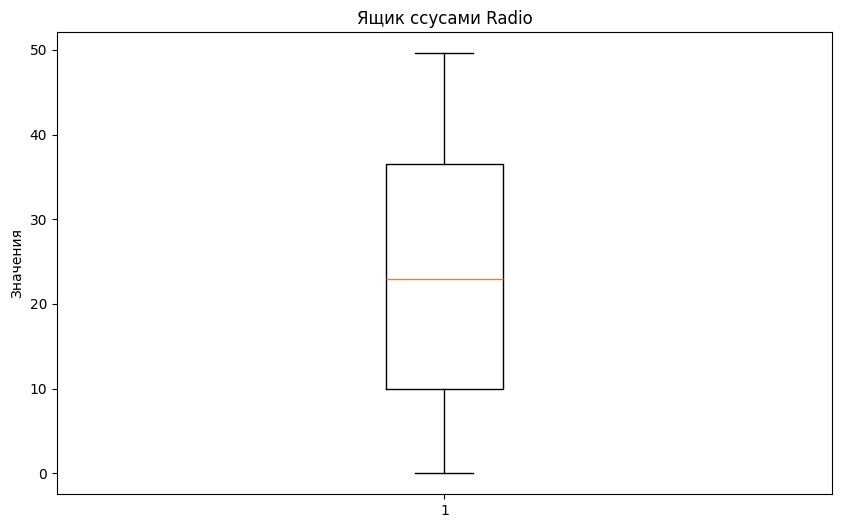

In [7]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['radio'])
plt.ylabel('Значения')
plt.title('Ящик сcусами Radio')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

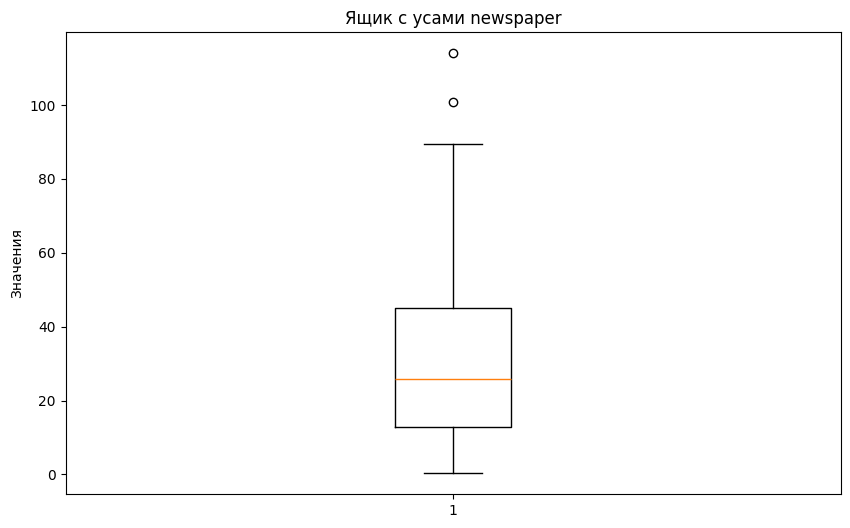

In [8]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['newspaper'])
plt.ylabel('Значения')
plt.title('Ящик с усами newspaper')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

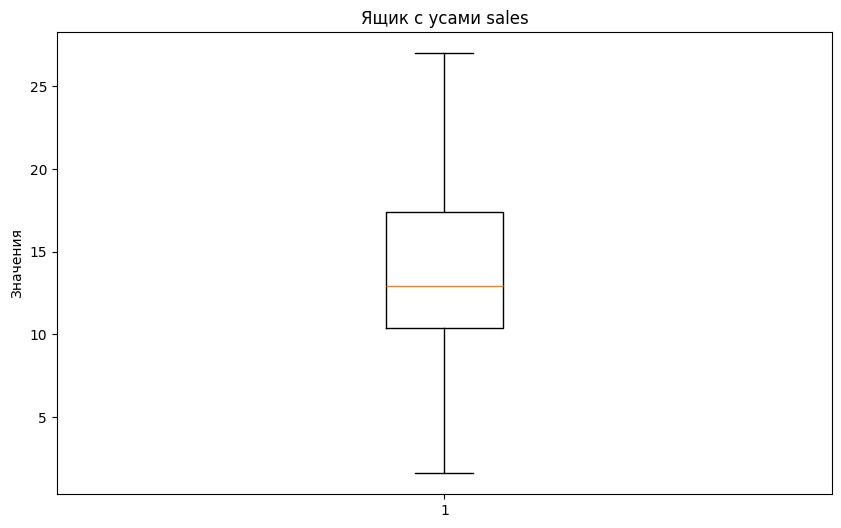

In [18]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['sales'])
plt.ylabel('Значения')
plt.title('Ящик с усами sales')
plt.show

Все данные, кроме newspaper не имеют выбросов.

Ниже уберу выбросы, которые мешают в newspaper, через межквартильных размах.

In [19]:
Q1 = df['newspaper'].quantile(0.25)  
Q3 = df['newspaper'].quantile(0.75) 
IQR = Q3 - Q1  


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df['newspaper'] >= lower_bound) & (df['newspaper'] <= upper_bound)]

X = df_cleaned[['TV', 'radio', 'newspaper']]
y = df_cleaned['sales'].values.reshape(-1, 1)

# Стандартизация
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

# Добавляю столбец единиц для intercept
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

# Разделение на обучающую и тестовую выборки (80/20)
train_size = int(0.8 * X_b.shape[0])
X_train, X_test = X_b[:train_size], X_b[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Инициализация весов
w = np.random.randn(X_b.shape[1], 1) * 0.01  

2. Реализация алгоритма

In [20]:
import matplotlib.pyplot as plt

# Градиентный спуск с L2-регуляризацией
alpha = 0.01 
lambda_reg = 0.001  
iterations = 300
loss_history = []


print(f"{'Итерация':<10} {'MSE':<12} " + " ".join([f'w{i:<12}' for i in range(w.shape[0])]))  
print("-" * (10 + 12 + 12 * w.shape[0])) 

for i in range(iterations):
    y_pred = X_train @ w
    mse = np.mean((y_pred - y_train) ** 2)
    loss_history.append(mse)

    # Вычисление градиента с регуляризацией
    grad = (2 / train_size) * X_train.T @ (y_pred - y_train) + lambda_reg * w
    
    w -= alpha * grad

    # Вывод значений
    print(f"{i:<10} {mse:<12.4f} " + " ".join(f"{w[j, 0]:<12.4f}" for j in range(w.shape[0])))


print(f"Финальные веса: {w.flatten()}")
print(f"Финальный MSE: {loss_history[-1]:.4f}")


Итерация   MSE          w0            w1            w2            w3           
----------------------------------------------------------------------
0          223.6163     0.2737       0.0561       0.0731       0.0245      
1          214.6263     0.5484       0.1236       0.1481       0.0622      
2          206.0133     0.8175       0.1899       0.2209       0.0981      
3          197.7610     1.0811       0.2551       0.2916       0.1325      
4          189.8539     1.3394       0.3192       0.3601       0.1652      
5          182.2770     1.5924       0.3822       0.4266       0.1964      
6          175.0160     1.8402       0.4442       0.4912       0.2262      
7          168.0573     2.0831       0.5051       0.5538       0.2545      
8          161.3880     2.3209       0.5649       0.6146       0.2814      
9          154.9956     2.5540       0.6238       0.6736       0.3071      
10         148.8683     2.7823       0.6817       0.7308       0.3314      
11         14

Получается что финальные веса стремятся к нулю, все верно. Градиент спускается относительно плавно

3. Визуализация.

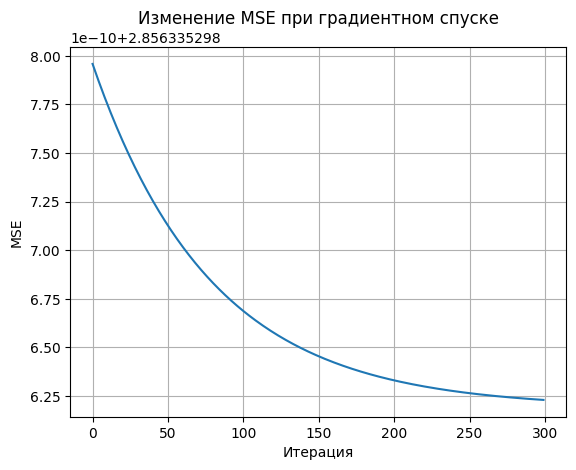

In [ ]:
plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Изменение MSE при градиентном спуске')
plt.grid()
plt.show()

На 300-х итерациях график аккуратно спускается к плато в районе 6.25
Это нормально, учитывая что я смотрю сразу по мультиколлинеарной регрессии. Значения разные, к полному нулю двигаются отдельные веса

4. Предсказание

MSE на тестовой выборке: 2.7561


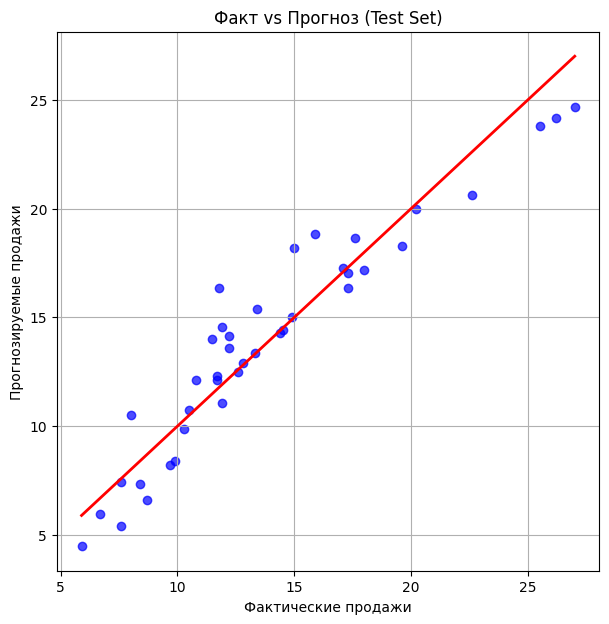

MSE на всей выборке 2.8387


In [17]:
y_pred_test = X_test @ w
mse_test = np.mean((y_pred_test - y_test)**2)
print(f"MSE на тестовой выборке: {mse_test:.4f}")


plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linewidth=2)

plt.xlabel("Фактические продажи")
plt.ylabel("Прогнозируемые продажи")
plt.title("Факт vs Прогноз (Test Set)")
plt.grid()
plt.show()


y_pred_all = X_b @ w
mse_all = np.mean((y_pred_all - y)**2)
print(f"MSE на всей выборке {mse_all:.4f}")

Таким образом, я вижу что квадратов остатков маловато конечно, но относительно того что у меня всего 200 значений и учет мульколлинеарности лучше построить будет сложновато. В целом скаттер не так далек от красной линии.